## 流式调用，批量调用和异步调用

In [5]:
from langchain.chat_models import init_chat_model


model = init_chat_model(
    model='deepseek-r1:8b',
    model_provider="ollama"
)

question = "写一首五言绝句"

for chunk in model.stream(question):
    print(chunk.text,end="",flush=True)




《五绝·夜泊》
孤舟一叶雪，远影入寒空。
何处笛声起，寒灯照客容。

赏析：这首作品以简练的五言绝句形式，勾勒出一幅孤寂夜泊图。首句“孤舟一叶雪”以舟与雪的意象叠加，营造出空灵寂寥的氛围；次句“远影入寒空”通过视觉延伸，强化了天地苍茫的意境。后两句转设问，借笛声与寒灯的虚实结合，巧妙传达出客居他乡的孤寒心境，余韵悠长，引人遐思。

## 批量调用
### 1》一次性接收所有响应

In [6]:
# 还是使用上面的模型，需要先运行上面的代码
msgs=[
    "土库曼斯坦的首都是哪里？","土库曼斯坦有多少女人？","土库曼斯坦的经济支柱是什么？"
]

responses = model.batch(msgs)
for res in responses:
    print(res.text)


土库曼斯坦的首都是**阿什哈巴德**（Ashgabat）。

截至2022年，土库曼斯坦的女性人口约为 **2,700,000人**（约537万总人口中女性占比约50%）。根据联合国人口统计，土库曼斯坦的性别比例大致平衡，男性略多于女性（男：女 ≈ 101:100）。不过，具体数字可能因数据来源和年份略有差异，建议参考官方发布的最新人口统计数据以获取更精确的信息。

土库曼斯坦的经济主要依赖于天然气和石油的出口，以及农业和棉花产业。该国拥有丰富的天然气和石油资源，这些资源是其经济的重要支柱。此外，土库曼斯坦的农业也是其经济的重要组成部分，尤其是棉花种植，为该国提供了大量的就业机会和收入。


## 2》按照完成的顺序接收响应,也就是那个任务先完成，就先输出它的结果，不一定按照输入顺序
### api: model. model.batch_as_completed([...,...])

In [8]:
from langchain.chat_models import init_chat_model


model = init_chat_model(
    model='deepseek-r1:8b',
    model_provider="ollama"
)

msgs=[
    "美国有多少女人","什么是美国的经济支柱","美国的体制有什么弊端"
]

responses = model.batch_as_completed(msgs) # 返回的是一个元组列表
for res in responses:
    print(res)

(1, AIMessage(content='\n美国经济是一个高度发达、多元化且复杂的经济体。其“支柱”并非单一的行业，而是由多个相互关联、共同支撑其经济运行和增长的关键组成部分构成。\n\n以下是支撑美国经济的主要支柱和关键行业：\n\n1.  **服务业（尤其是知识密集型服务业）**：这是美国经济最大的部分，也是其最具代表性的支柱。\n    *   **金融服务业**：包括华尔街的大型投资银行、证券交易所、保险公司和众多跨国金融公司。美国拥有全球最强大的金融体系，美元是全球主要储备货币和结算货币。\n    *   **专业和商业服务业**：涵盖咨询、法律、会计、广告、管理和科学等行业，是企业运作和创新的核心支持。\n    *   **医疗保健**：美国医疗系统庞大且资本密集，是巨大的雇主和经济贡献者。\n    *   **信息技术和软件开发**：硅谷是其代名词，美国是全球信息技术产业的领导者，包括硬件、软件、互联网服务等。\n    *   **教育**：不仅提供人力资源，其顶尖的大学（如常春藤盟约）在全球范围内吸引巨额资金和人才。\n\n2.  **能源产业**：\n    *   **石油和天然气**：虽然美国近年来通过页岩气革命成为能源生产大国甚至出口国，但作为全球最大的石油进口国之一，其庞大的能源需求（尤其是航空、汽车和工业）仍然使其成为经济的关键环节。\n    *   **可再生能源**：风能、太阳能等产业在美国经济中增长迅速，是未来重要的发展方向。\n    *   **核能**：也是美国能源结构的一部分。\n\n3.  **高科技和创新驱动**：这与信息技术、生物技术和航空航天等领域紧密相关，是美国保持其经济领先地位的核心因素。研发支出巨大，成果转化能力强。\n\n4.  **农业**：\n    *   虽然仅占GDP的一小部分，但美国农业是规模化的，高度依赖科技，并且是重要的出口部门，被称为“世界粮仓”。\n\n5.  **制造业**：\n    *   经历了从传统制造到高科技制造的转型。虽然在全球供应链和贸易政策的影响下，部分制造业岗位有所流失，但航空航天、汽车（尤其是电动汽车和零部件制造）、电子设备、机械设备、化学品等仍然是重要的制造中心和出口部门。\n    *   近年来，“再工业化”趋势和先进制造技术的应用使其重要性有所

In [12]:
msgs=[
    "做爱的英文","裂痕的英文","10的对数"
]

responses = model.batch_as_completed(msgs) 
for res in responses:
    idx,ai = res
    print(ai.text)


“做爱”的英文取决于具体的语境：

1.  **谈论性行为：**
    *   **Have sex:** 这是最常用、最中性的说法。它泛指任何形式的性行为，不指定性别，也可以用于谈论与伴侣的性行为。
    *   **Have intercourse:** 这个说法更正式一些，也泛指性行为。
    *   **Make love:** 这个说法通常带有更浪漫或情感上的色彩，指情侣之间充满爱意的性行为。比较少见，但有时用于强调情感深度。
    *   **Be intimate:** 意思是“进行亲密行为”，更广泛地指亲密接触，包括性行为。
    *   **Go to bed:** 这是一个常见的俚语，意思是“发生性关系”，通常指伴侣之间。

2.  **谈论结婚：**
    *   **Get married:** 意思是“结婚”。
    *   **Get hitched:** 俚语，意思是“结婚”。
    *   **Get wed:** 意思是“结婚”。
    *   **Get married (to sb):** 结婚给某人。

**需要注意：**

*   **礼貌性：** 在英语中，谈论性行为通常比中文的“做爱”要稍微委婉一些。即使是像 **have sex** 这样直接的说法，在正式或礼貌的场合也可能被认为太直接。更委婉的说法可能包括 **engage in sexual intercourse** 或 **have sexual relations**。
*   **避免粗俗：** 不要使用俚语或过于粗俗的词汇，比如 **fuck**（虽然 **having a fuck** 可以指性行为，但这非常不礼貌且不标准）。

选择哪个词取决于你想表达的具体含义以及对话的语境。一般来说，**have sex** 和 **have intercourse** 是最常用和最安全的选择。

Crack

“10的对数”通常指的是以10为底的对数函数（常用对数），即 log₁₀(10)。

log₁₀(10) 的值是 1，因为 10 的 1 次方等于 10。

如果您的意思是其他底数的对数（例如自然对数 ln(10)），或者有其他具体问题，请提供更多细节，我可以进一步解释！


## 性能对比

In [ ]:
import time

inputs = [
       "翻译为英文：春天来了",
       "翻译为英文：夏天很热",
       "翻译为英文：秋天落叶",
       "翻译为英文：冬天下雪"
]

start = time.time()
resps = model.batch(inputs)
for res in resps:
    print(res.text)
batch_time = time.time() - start
print(f"batch:{batch_time}")

start = time.time()
for i in inputs:
    res = model.invoke(i)
    print(res)
loop_invoke_time = time.time() - start
print(f"loop_invoke_time:{loop_invoke_time}")

 


Spring has come

Summer is very hot.

Leaves fall in autumn.

Snow in winter
batch:214.13640308380127
content='\nSpring has come' additional_kwargs={} response_metadata={'model': 'deepseek-r1:8b', 'created_at': '2026-09-07T23:11:30.9298003Z', 'done': True, 'done_reason': 'stop', 'total_duration': 62446592900, 'load_duration': 4238700, 'prompt_eval_count': 9, 'prompt_eval_duration': 391321000, 'eval_count': 271, 'eval_duration': 61994927000, 'logprobs': None, 'model_name': 'deepseek-r1:8b', 'model_provider': 'ollama'} id='lc_run--01a07e23-2881-7d72-8eee-ce6859bac67a-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 9, 'output_tokens': 271, 'total_tokens': 280}
content='\nSummer is very hot.' additional_kwargs={} response_metadata={'model': 'deepseek-r1:8b', 'created_at': '2026-09-07T23:12:52.6980095Z', 'done': True, 'done_reason': 'stop', 'total_duration': 81763997600, 'load_duration': 6961200, 'prompt_eval_count': 10, 'prompt_eval_duration': 505052000, 'eval_count

## 异步调用
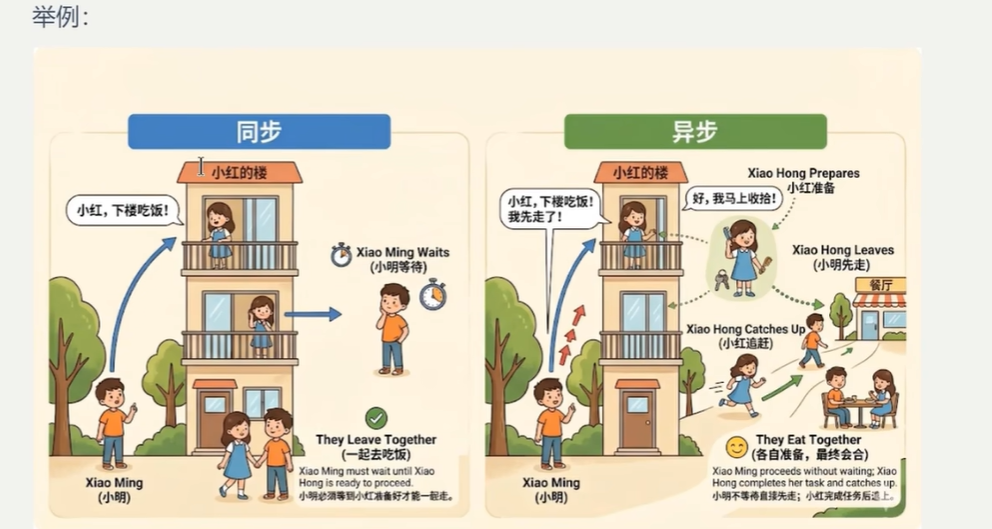